## Упражнение 2.2

Добавляем путь к папке code для получения доступа к классам и функциям thinkdsp.

In [1]:
from pathlib import Path
import sys

current_path = Path.cwd()
code_path = current_path.parent / 'code'
sys.path.append(str(code_path))

In [9]:
import numpy as np
from thinkdsp import Signal
PI2 = np.pi * 2

def normalize(ys, amp=1.0):
    high, low = abs(max(ys)), abs(min(ys))
    return amp * ys / max(high, low)

class SawtoothSignal(Signal):
    def __init__(self, freq=440, amp=1.0, offset=0, func=np.sin):
        self.freq = freq
        self.amp = amp
        self.offset = offset
        self.func = func

    @property
    def period(self):
        return 1.0 / self.freq

    def evaluate(self, ts):
        cycles = self.freq * ts + self.offset / PI2
        frac, _ = np.modf(cycles)
        ys = normalize(frac - frac.mean(), self.amp)
        return ys

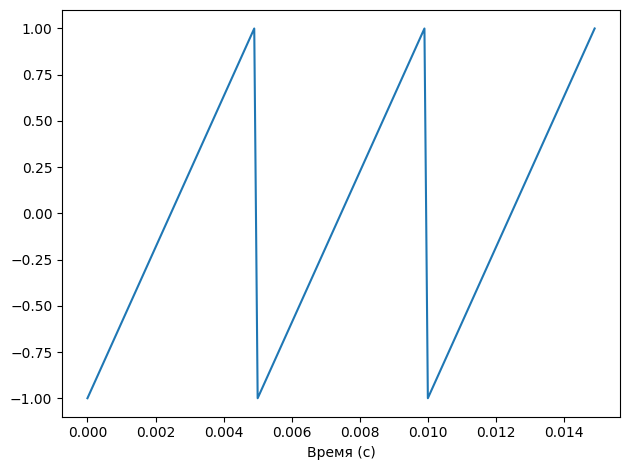

In [12]:
from thinkdsp import decorate

sawsignal = SawtoothSignal(200)
duration = sawsignal.period * 3
segment = sawsignal.make_wave(duration, framerate=10000)
segment.plot()
decorate(xlabel = 'Время (с)')

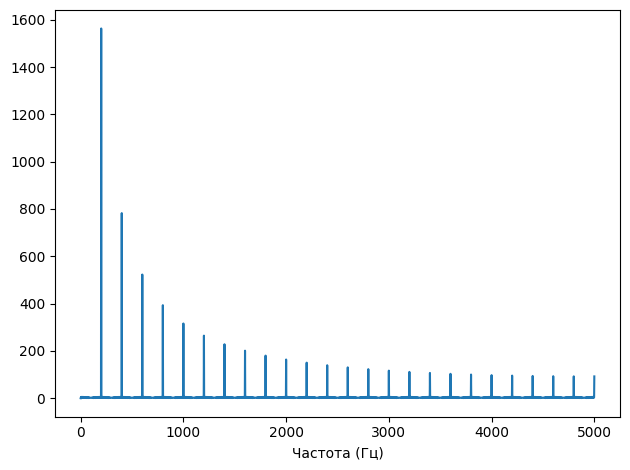

In [13]:
wave = sawsignal.make_wave(duration=0.5, framerate=10000)
spectrum = wave.make_spectrum()
spectrum.plot()
decorate(xlabel='Частота (Гц)')

У пилообразного сигнала есть чётные и нечётные гармоники. Амплитуда спадает пропорционально частота, как в случае прямоугольного сигнала.

## Упражнение 2.3

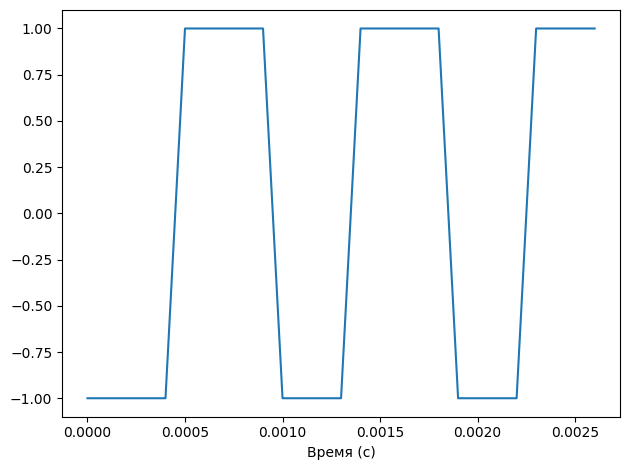

In [33]:
from thinkdsp import SquareSignal

square = SquareSignal(1100)
duration = square.period*3
segment = square.make_wave(duration, framerate=10000)
segment.plot()
decorate(xlabel='Время (с)')

Уже на данном этапе можем заметить эффект заворачиваний из-за биений. Мы должны были увидеть идеальную прямоугольную картину, как представлено ниже при другом значении кадров в секунду.

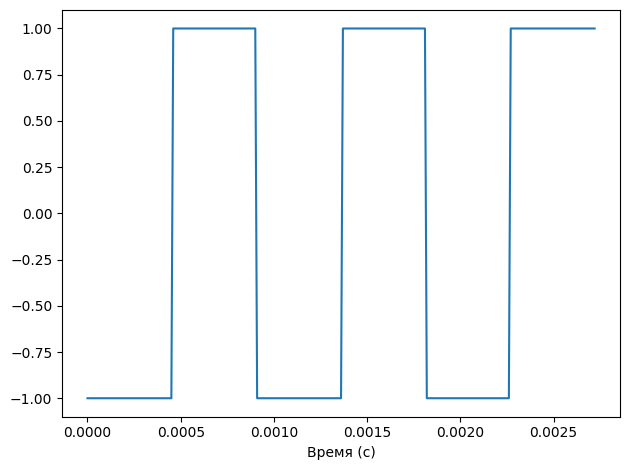

In [34]:
segment2 = square.make_wave(duration, framerate=100000)
segment2.plot()
decorate(xlabel='Время (с)')

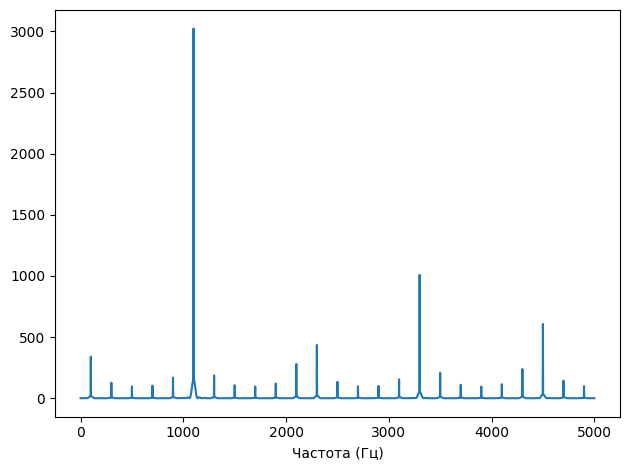

In [37]:
wave = square.make_wave(duration=0.5, framerate=10000)
wave.apodize()
spectrum = wave.make_spectrum()
spectrum.plot()
decorate(xlabel='Частота (Гц)')

Получили, что несущая частота не обладает максимальной амплитудой, что странно для прямоугольного сигнала. Это проявление биений. Сравним с тем, что должно быть.

In [39]:
wave.make_audio()

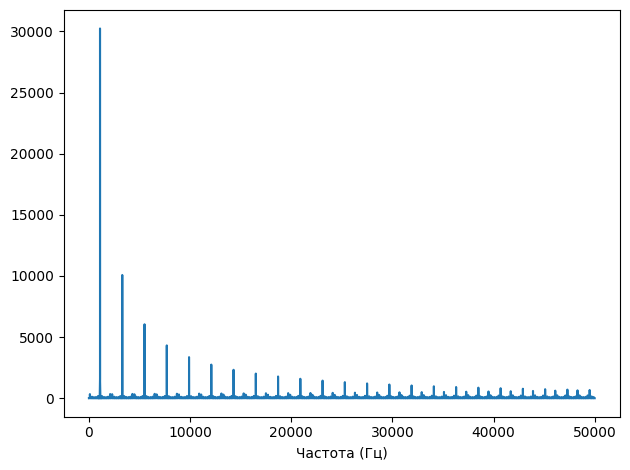

In [38]:
wave = square.make_wave(duration=0.5, framerate=100000)
wave.apodize()
spectrum = wave.make_spectrum()
spectrum.plot()
decorate(xlabel='Частота (Гц)')

In [40]:
wave.make_audio()

Тем не менее, при проигрывании различить отличия человеческим слухот трудно.

## Упражнение 2.4

In [42]:
from thinkdsp import TriangleSignal

signal = TriangleSignal(440)
wave = signal.make_wave(duration=0.01, framerate=1000)
spectrum = wave.make_spectrum()
spectrum.hs[0]

np.complex128(-1.0547118733938987e-15+0j)

В данном случае фаза равно 0, а амплитуда равна удвоенному значению модуля действительной части (размах) 2.1094237467877974e-15.

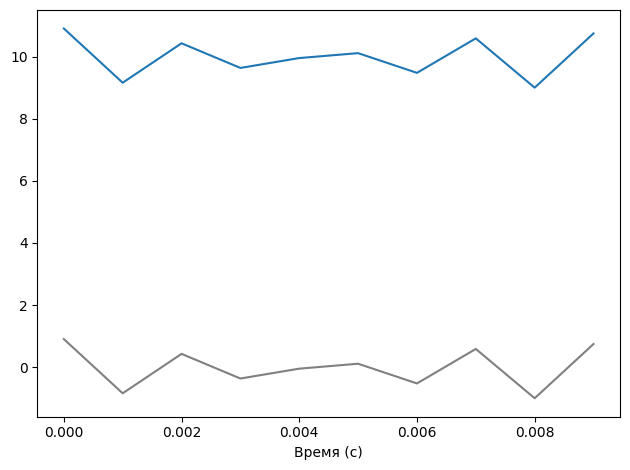

In [44]:
spectrum.hs[0] = 100
wave.plot(color='gray')
spectrum.make_wave().plot()
decorate(xlabel='Время (с)')

Операция spectrum.hs[0] = 100 приводит к увеличению амплитуды.

## Упражнение 2.5

In [45]:
def divide_hs(spectrum):
    spectrum.hs[0] = 0
    for i in range(1, len(spectrum.hs)):
        spectrum.hs[i] = spectrum.hs[i] / spectrum.fs[i]
    return spectrum

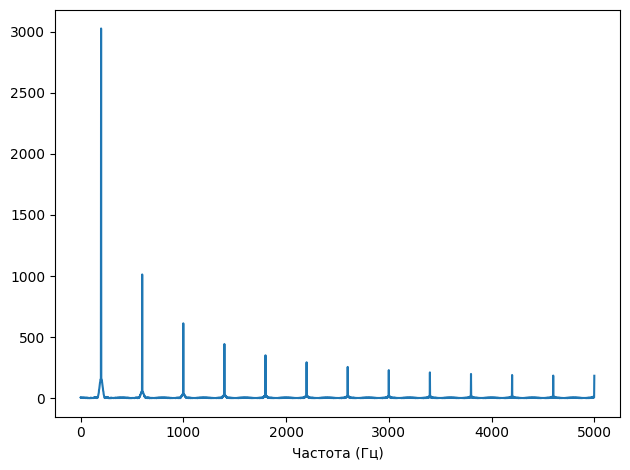

In [48]:
signal = SquareSignal(200)
wave = signal.make_wave(duration=0.5, framerate=10000)
wave.apodize()
spectrum = wave.make_spectrum()
spectrum.plot()
decorate(xlabel='Частота (Гц)')

In [49]:
wave.make_audio()

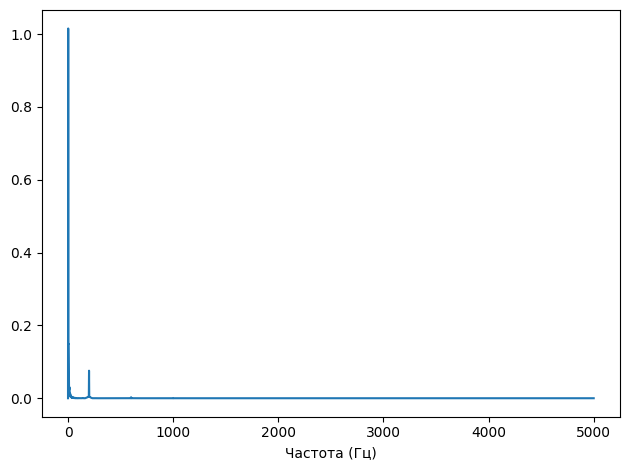

In [51]:
spectrum = divide_hs(spectrum)
spectrum.plot()
decorate(xlabel='Частота (Гц)')

In [52]:
wave = spectrum.make_wave()
wave.make_audio()

Функция подавляет гармоники, из-за чего аудио начинает звучать более приглушённо.

## Упражнение 2.6

Если нам требуется сигнал как с чётными, так и нечётными гармониками, то логично воспользоваться пилообразным сигналом: инициализировать его и изменить параметры, изменив характер изменения амплитуды.

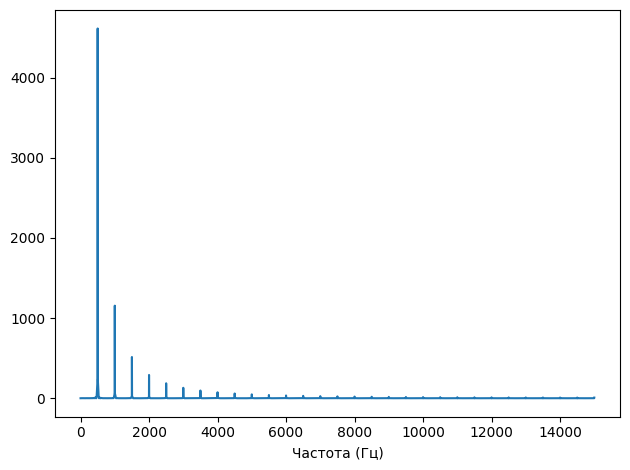

In [70]:
freq = 500

signal = SawtoothSignal(freq)
wave = signal.make_wave(duration=0.5, framerate=30000)
wave.apodize()
spectrum = wave.make_spectrum()
spectrum = divide_hs(spectrum)
spectrum.scale(freq)
spectrum.plot()
decorate(xlabel='Частота (Гц)')